## Seleção de Variáveis com Stepwise, Lasso e SFS

### 🎓 Introdução 

Este notebook explora **três abordagens clássicas** de seleção de variáveis para regressão:

- Stepwise (via AIC)
- Lasso (L1 Regularization)
- SFS (Sequential Feature Selection via validação cruzada)

Cada técnica possui vantagens e limitações, discutidas no final. O objetivo é construir modelos mais parcimoniosos, reduzindo o overfitting e aumentando interpretabilidade.

---

In [2]:
!pip install mlxtend
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import datasets
import statsmodels.api as sm
import matplotlib.pyplot as plt
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import seaborn as sns

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.4 MB 487.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.4 MB 939.4 kB/s eta 0:00:02
   --- ------------------------------------ 0.1/1.4 MB 798.9 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.4 MB 1.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.4 MB 1.4 MB/s eta 0:00:01
   --------------- ------------------------ 0.5/1.4 MB 1.9 MB/s eta 0:00:01
   ---------------- ----------------------- 0.5/1.4 MB 1.6 MB/s eta 0:00:01
   ---------------------- ----------------- 0.8/1.4 MB 2.0 MB/s eta 0:00:01
   ------------------------------- -------- 1.1/1.4 MB 2.5 MB/s eta 0:00:01
   ------------------------------------ --- 1.2/1.4 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.7 MB/s eta 0:00:00
   -----------------

**Importando o Dataset**

Dataset de diabetes embutido no sklearn

In [3]:
data = datasets.load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='progressao')
db_df = pd.concat([X, y], axis=1)
db_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progressao
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Contextualização:

O conjunto de dados de diabetes usado neste exemplo é proveniente do sklearn.datasets. As variáveis presentes no conjunto de dados são:

*   age: Idade do paciente.
*   sex: Gênero do paciente (0: feminino, 1: masculino).
*   bmi: Índice de massa corporal (IMC).
*   bp: Pressão arterial média.
*   s1: Total de soro de lipoproteína de alta densidade (HDL).
*   s2: Total de soro de lipoproteína de baixa densidade (LDL).
*   s3: Total de soro de triglicerídeos.
*   s4: Total de soro de total de lipoproteína.
*   s5: Total de soro de ácido sérico.
*   s6: Total de soro de lamotrigina.
Cada uma dessas variáveis representa diferentes características médicas e fisiológicas dos pacientes.

O objetivo é prever a medida quantitativa da progressão da doença diabética após um ano com base nessas características. O valor alvo (target) é uma medida quantitativa da progressão da doença.

Verificando os dados carregados

In [4]:
db_df.isna().sum() #verificando valores ausentes

age           0
sex           0
bmi           0
bp            0
s1            0
s2            0
s3            0
s4            0
s5            0
s6            0
progressao    0
dtype: int64

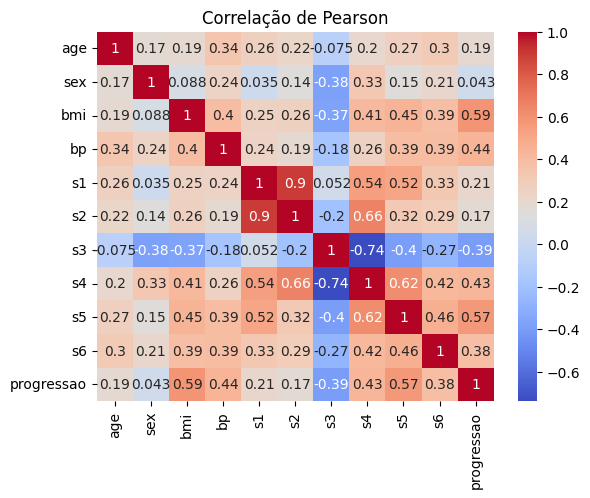

In [5]:
corr_pearson = db_df.corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm")
plt.title("Correlação de Pearson")
plt.show()

Maiores correlações com a progressão :
   - bmi : 0.59
   - s5 : 0.57
   - bp : 0.44
   - s4 : 0.43
   - s3: 0.39

   -   ['bmi', 's5', 'bp', 's1', 's2', 'sex']

Divisão da base - Treino e Teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Separa os dados em treino (80%) e teste (20%)

### Stepwise com AIC

**Teoria:**
**Stepwise Selection** é uma técnica que combina forward e backward selection, usando métricas como AIC.
- AIC penaliza modelos complexos.
- Permite encontrar subconjuntos de variáveis com bom poder preditivo sem overfitting.

In [7]:
def calculate_aic(model, X, y):
    n = len(y)
    k = X.shape[1] + 1  # número de parâmetros, incluindo o intercepto
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    aic = n * np.log(mse) + 2 * k
    return aic

AIC = métrica que penaliza modelos com muitos parâmetros, ajuda a selecionar o modelo mais parcimonioso

### Implementação Stepwise Forward + Backward

Iremos criar as seguintes variáveis:

- selected_features: Lista que armazenará as variáveis selecionadas durante o procedimento.
- stepwise_model: Modelo de regressão linear a ser ajustado.
- best_aic: Variável que armazenará o menor AIC encontrado.

No python é necessário criar a função para realizar o stepwise

Seleção de variáveis com Stepwise (avançando e removendo as variáveis com base no menor AIC)

In [8]:
def forward_backward_stepwise_selection(X, y):
    selected = []
    best_aic = float('inf')
    model = LinearRegression()

    while True:
        changed = False
        candidates = [col for col in X.columns if col not in selected]
        best_candidate, best_model = None, None

        for feat in candidates:
            model.fit(X[selected + [feat]], y)
            aic = calculate_aic(model, X[selected + [feat]], y)
            if aic < best_aic:
                best_aic, best_candidate = aic, feat
                changed = True

        if changed:
            selected.append(best_candidate)
        else:
            break

    return selected

In [9]:
# Retorna lista de variáveis selecionadas pelo critério de AIC
selected_stepwise = forward_backward_stepwise_selection(X_train, y_train)
print("Selecionadas pelo Stepwise:", selected_stepwise)


Selecionadas pelo Stepwise: ['bmi', 's5', 'bp', 's1', 's2', 'sex']


**Treinando modelo com variáveis selecionadas**

Ajuste do modelo Linear com as variáveis escolhidas

In [10]:
model_sw = LinearRegression().fit(X_train[selected_stepwise], y_train)
y_pred_sw = model_sw.predict(X_test[selected_stepwise])

**Avaliação do modelo Stepwise**

Calcular as métricas de avaliação para o modelo Stepwise

In [11]:
n = len(y_test)
k = len(selected_stepwise)
mse = mean_squared_error(y_test, y_pred_sw)
aic = n * np.log(mse) + 2 * k
bic = n * np.log(mse) + k * np.log(n)

results = [{
    'Modelo': 'Stepwise',
    'MAE': mean_absolute_error(y_test, y_pred_sw),
    'MSE': mse,
    'AIC': aic,
    'BIC': bic,
    'R²': model_sw.score(X_test[selected_stepwise], y_test)
}]

In [12]:
pd.DataFrame(results)

,Modelo,MAE,MSE,AIC,BIC,R²
0,Stepwise,42.61109,2846.290524,719.885695,734.817513,0.462777


### SFS (Sequential Feature Selector)

O **SFS (mlxtend)** realiza seleção de variáveis de forma sequencial:
- `forward=True`: começa com nenhuma variável e vai adicionando.
- `floating=True`: permite remoção/backward no meio do processo.
- Permite validação cruzada com métrica personalizada (ex: MSE).

In [13]:
sfs_model = SFS(LinearRegression(), 
                k_features='best', 
                forward=True, 
                floating=True,  # Ativa stepwise (entra e remove variáveis)
                scoring='neg_mean_squared_error', 
                cv=5)

sfs_model.fit(X_train, y_train)
print("Variáveis selecionadas pelo SFS:", list(sfs_model.k_feature_names_))

Variáveis selecionadas pelo SFS: ['sex', 'bmi', 'bp', 's1', 's2', 's5']


In [14]:
print("Selecionadas pelo Stepwise:", selected_stepwise)

Selecionadas pelo Stepwise: ['bmi', 's5', 'bp', 's1', 's2', 'sex']


**Avaliação do modelo SFS**

In [15]:
selected_sfs = list(sfs_model.k_feature_names_)
model_sfs = LinearRegression().fit(X_train[selected_sfs], y_train)
y_pred_sfs = model_sfs.predict(X_test[selected_sfs])

n = len(y_test)
k = len(selected_sfs)
mse = mean_squared_error(y_test, y_pred_sfs)
aic = n * np.log(mse) + 2 * k
bic = n * np.log(mse) + k * np.log(n)

results.append({
    'Modelo': 'SFS (mlxtend)',
    'MAE': mean_absolute_error(y_test, y_pred_sfs),
    'MSE': mse,
    'AIC': aic,
    'BIC': bic,
    'R²': model_sfs.score(X_test[selected_sfs], y_test)
})

In [16]:
pd.DataFrame(results)

,Modelo,MAE,MSE,AIC,BIC,R²
0,Stepwise,42.61109,2846.290524,719.885695,734.817513,0.462777
1,SFS (mlxtend),42.61109,2846.290524,719.885695,734.817513,0.462777


### ***Lasso (L1 Regularization)***

O **Lasso** aplica uma penalização  L1 que força alguns coeficientes a serem zero:
- Elimina variáveis irrelevantes automaticamente.
- Útil quando há muitas variáveis correlacionadas.
- O parâmetro alpha controla a intensidade da penalização.

In [17]:
alphas = np.logspace(-4, 4, 100)
lasso_cv = GridSearchCV(Lasso(), {'alpha': alphas}, cv=5)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.best_params_['alpha']

# Modelo final com o melhor alpha encontrado
lasso_final = Lasso(alpha=best_alpha).fit(X_train, y_train)

# Coeficientes diferentes de zero indicam variáveis selecionadas
lasso_coef = lasso_final.coef_
selected_lasso = X.columns[lasso_coef != 0]
print("Selecionadas pelo Lasso:", list(selected_lasso))

Selecionadas pelo Lasso: ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


In [18]:
y_pred_lasso = lasso_final.predict(X_test)

n = len(y_test)
k = len(selected_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
aic = n * np.log(mse) + 2 * k
bic = n * np.log(mse) + k * np.log(n)

results.append({
    'Modelo': 'Lasso',
    'MAE': mean_absolute_error(y_test, y_pred_lasso),
    'MSE': mse,
    'AIC': aic,
    'BIC': bic,
    'R²': lasso_final.score(X_test, y_test)
})

### Comparando os modelos

In [19]:
results_df = pd.DataFrame(results)
print(results_df)

          Modelo       MAE          MSE         AIC         BIC        R²
0       Stepwise  42.61109  2846.290524  719.885695  734.817513  0.462777
1  SFS (mlxtend)  42.61109  2846.290524  719.885695  734.817513  0.462777
2          Lasso  42.80031  2799.827946  720.420879  737.841334  0.471546


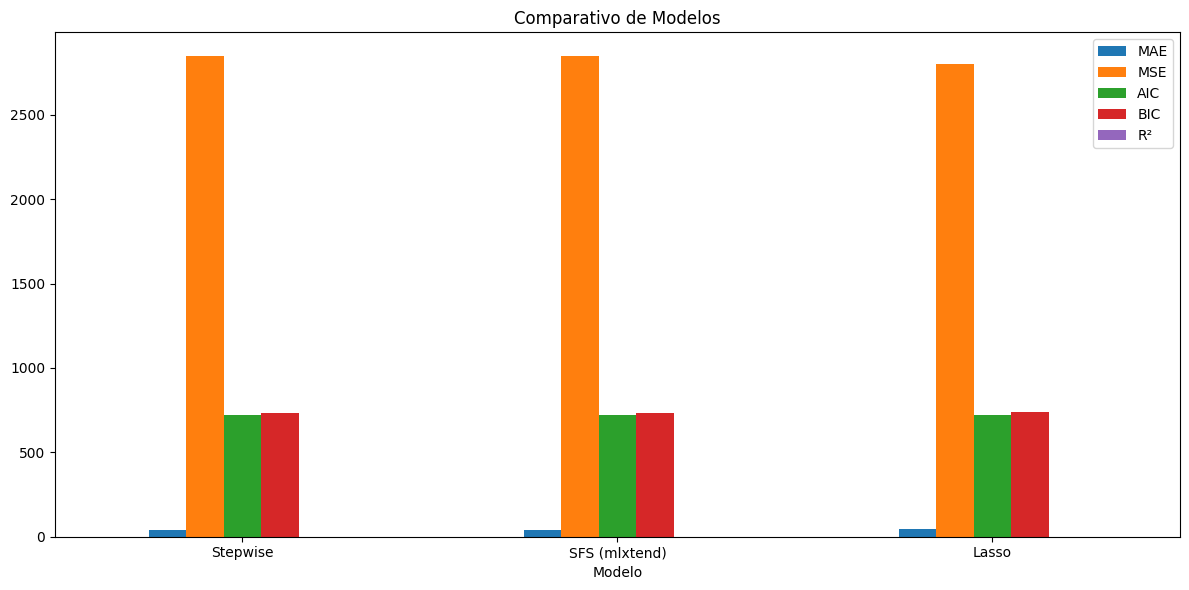

In [20]:
results_df.set_index('Modelo')[['MAE', 'MSE', 'AIC', 'BIC', 'R²']].plot(kind='bar', figsize=(12,6), title='Comparativo de Modelos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Usando o melhor valor de alpha para treinar o modelo final

### 📌 Conclusões Didáticas
- **Stepwise**: bom ponto de partida, mas pode gerar overfitting.
- **Lasso**: ótimo para regularização e eliminar colinearidade.
- **SFS**: flexível e robusto com validação cruzada, porém mais lento.

### 🚀 Recomendado para prática:
- Compare com métricas AIC/BIC/R² para justificar escolha final.
